Loaded: 372 ROIs, 98 trials, 130 spatial bins
Temporal: 13290 frames across 98 laps
Reliable (somatic criteria): 113 / 372

Distance-to-reward: range [0.0, 126.7] cm

Active axons (permissive filter): 372 / 372
  vs. somatic reliability filter:  113 / 372
  Overlap: 113

Bin spacing: 1.00 cm
Corridor length: 129.0 cm


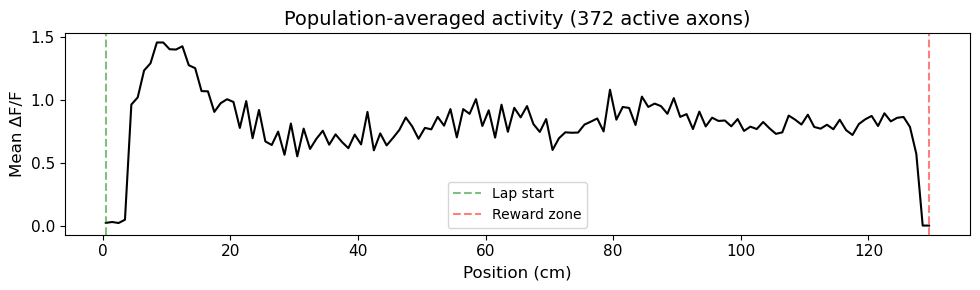

In [1]:
"""
Chunk 1: Data Loading & Setup
Load preprocessed HDF5 and prepare variables for axonal spatial analysis.
"""

import os
import sys
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib import rcParams

sys.path.insert(0, r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation")
from helper import files

rcParams['legend.fontsize'] = 12
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 14
rcParams['xtick.labelsize'] = 11
rcParams['ytick.labelsize'] = 11

# ── 1. Load preprocessed data ──────────────────────────────────────────────
data_filepath = r"D:\V1_SpatialModulation\2p\V1_window\JSY061_ChronicImaging_Axonal\260202_JSY_JSY061_SpMod_AxonalImaging_Day1\TSeries-02022026-1804-001"
preproc_files = [f for f in os.listdir(data_filepath) if f.endswith('preproc.h5')]
assert len(preproc_files) > 0, "No preprocessed .h5 file found!"
preproc_path = os.path.join(data_filepath, preproc_files[0])

preproc = files.read_h5(preproc_path)

# Spatial data  (n_cells, n_trials, n_bins)
spatial_activity     = preproc['spatial_activity']
norm_spatial_activity = preproc['norm_spatial_activity']
bin_centers          = preproc['bin_centers']
reliable_cells       = preproc['combined_reliable'].astype(bool)

# Temporal data (continuous across laps)
temporal_spikes  = preproc['smoothed_spks_temporal']   # (n_cells, n_frames)
temporal_location = preproc['location_cm']              # (n_frames,)
temporal_speed    = preproc['speed_cm_s']               # (n_frames,)
lap_starts        = preproc['lap_starts'].astype(int)
lap_ends          = preproc['lap_ends'].astype(int)

n_cells, n_trials, n_bins = spatial_activity.shape
n_frames = temporal_spikes.shape[1]
n_laps   = len(lap_starts)

print(f"Loaded: {n_cells} ROIs, {n_trials} trials, {n_bins} spatial bins")
print(f"Temporal: {n_frames} frames across {n_laps} laps")
print(f"Reliable (somatic criteria): {np.sum(reliable_cells)} / {n_cells}")

# ── 2. Compute distance-to-reward for each frame ───────────────────────────
#    In your corridor, reward is at the end of each lap.
#    distance_to_reward = max_location_in_lap - current_location

lap_max_locations = np.array([
    np.max(temporal_location[s:e]) for s, e in zip(lap_starts, lap_ends)
])

distance_to_reward = np.zeros(n_frames)
for i, (s, e) in enumerate(zip(lap_starts, lap_ends)):
    distance_to_reward[s:e] = lap_max_locations[i] - temporal_location[s:e]

print(f"\nDistance-to-reward: range [{distance_to_reward.min():.1f}, {distance_to_reward.max():.1f}] cm")

# ── 3. Define active ROIs for axonal analysis ──────────────────────────────
#    For axons, the somatic reliability criteria (sharp peaks, high CC) are
#    too strict. Instead, use a permissive activity filter:
#    any ROI with mean activity > 0 and at least some transients.

mean_activity = np.mean(temporal_spikes, axis=1)
active_fraction = np.mean(temporal_spikes > 0, axis=1)  # fraction of frames with activity

# Permissive threshold: mean > 0 and active in at least 1% of frames
AXON_ACTIVITY_THRESHOLD = 0.01
active_axons = (mean_activity > 0) & (active_fraction > AXON_ACTIVITY_THRESHOLD)

print(f"\nActive axons (permissive filter): {np.sum(active_axons)} / {n_cells}")
print(f"  vs. somatic reliability filter:  {np.sum(reliable_cells)} / {n_cells}")
print(f"  Overlap: {np.sum(active_axons & reliable_cells)}")

# ── 4. Shifted/scaled bin centers (matching your SMI pipeline) ─────────────
shifted_centers = bin_centers - np.min(bin_centers)
scaled_bin_centers = shifted_centers * (n_bins / np.max(shifted_centers))
bin_spacing_cm = np.mean(np.diff(bin_centers))

print(f"\nBin spacing: {bin_spacing_cm:.2f} cm")
print(f"Corridor length: {np.max(bin_centers) - np.min(bin_centers):.1f} cm")

# ── 5. Quick sanity plot: mean activity across corridor ────────────────────
pop_mean = np.mean(spatial_activity[active_axons], axis=(0, 1))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(bin_centers, pop_mean, 'k-', lw=1.5)
ax.set_xlabel('Position (cm)')
ax.set_ylabel('Mean ΔF/F')
ax.set_title(f'Population-averaged activity ({np.sum(active_axons)} active axons)')
ax.axvline(bin_centers[0], color='green', ls='--', alpha=0.5, label='Lap start')
ax.axvline(bin_centers[-1], color='red', ls='--', alpha=0.5, label='Reward zone')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
"""
Chunk 2: Spatial Tuning Curves + Spatial Information Content
Computes Skaggs spatial information (bits/spike) with circular-shuffle
bias correction. Designed for axonal calcium imaging data.
"""

import numpy as np
from scipy.ndimage import gaussian_filter1d

# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 1: Compute spatial tuning curve from temporal data
# ═══════════════════════════════════════════════════════════════════════════
def compute_tuning_curve(activity_1d, location, bin_edges, min_occupancy=2):
    """
    Compute spatial tuning curve (mean activity per spatial bin) from
    continuous temporal data.
    
    Parameters
    ----------
    activity_1d : (n_frames,) array — one ROI's activity trace
    location    : (n_frames,) array — position in cm
    bin_edges   : (n_bins+1,) array — spatial bin edges
    min_occupancy : int — minimum frames per bin to compute rate
    
    Returns
    -------
    tuning_curve : (n_bins,) — mean activity per bin (NaN if < min_occupancy)
    occupancy    : (n_bins,) — frame count per bin
    """
    n_bins = len(bin_edges) - 1
    tuning_curve = np.full(n_bins, np.nan)
    occupancy = np.zeros(n_bins, dtype=int)
    
    bin_idx = np.digitize(location, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    
    for b in range(n_bins):
        mask = bin_idx == b
        occupancy[b] = np.sum(mask)
        if occupancy[b] >= min_occupancy:
            tuning_curve[b] = np.mean(activity_1d[mask])
    
    return tuning_curve, occupancy


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 2: Skaggs spatial information (bits/spike)
# ═══════════════════════════════════════════════════════════════════════════
def skaggs_spatial_info(tuning_curve, occupancy):
    """
    Skaggs et al. (1993) spatial information in bits per spike.
    
        SI = Σ_i  p_i * (λ_i / λ_mean) * log2(λ_i / λ_mean)
    
    where p_i = occupancy fraction, λ_i = bin rate, λ_mean = overall mean rate.
    
    Parameters
    ----------
    tuning_curve : (n_bins,) — mean activity per bin
    occupancy    : (n_bins,) — frame count per bin
    
    Returns
    -------
    si_bits_spike : float — spatial information in bits/spike
    si_bits_sec   : float — spatial information in bits/second (SI * mean_rate)
    mean_rate     : float — overall mean activity
    """
    valid = ~np.isnan(tuning_curve) & (occupancy > 0)
    if np.sum(valid) < 3:
        return np.nan, np.nan, np.nan
    
    tc = tuning_curve[valid]
    occ = occupancy[valid].astype(float)
    
    # Occupancy probability
    p_i = occ / np.sum(occ)
    
    # Mean rate (occupancy-weighted)
    mean_rate = np.sum(p_i * tc)
    
    if mean_rate <= 0:
        return np.nan, np.nan, 0.0
    
    # Skaggs formula — only include bins with activity > 0
    pos_mask = tc > 0
    if np.sum(pos_mask) == 0:
        return 0.0, 0.0, mean_rate
    
    ratio = tc[pos_mask] / mean_rate
    si_bits_spike = np.sum(p_i[pos_mask] * ratio * np.log2(ratio))
    si_bits_sec = si_bits_spike * mean_rate
    
    return si_bits_spike, si_bits_sec, mean_rate


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 3: Circular shuffle for significance testing + bias correction
# ═══════════════════════════════════════════════════════════════════════════
def circular_shuffle_si(activity_1d, location, bin_edges, n_shuffles=500,
                        min_shift_frac=0.1):
    """
    Compute null distribution of spatial information by circularly shifting
    the activity trace relative to position. Preserves temporal autocorrelation.
    
    Parameters
    ----------
    activity_1d   : (n_frames,) array
    location      : (n_frames,) array
    bin_edges     : (n_bins+1,) array
    n_shuffles    : int — number of shuffles
    min_shift_frac : float — minimum shift as fraction of trace length
    
    Returns
    -------
    shuffle_si : (n_shuffles,) — null SI values (bits/spike)
    """
    n = len(activity_1d)
    min_shift = int(n * min_shift_frac)
    max_shift = n - min_shift
    
    shuffle_si = np.zeros(n_shuffles)
    
    for s in range(n_shuffles):
        shift = np.random.randint(min_shift, max_shift)
        shifted_activity = np.roll(activity_1d, shift)
        tc_shuf, occ_shuf = compute_tuning_curve(shifted_activity, location, bin_edges)
        shuffle_si[s], _, _ = skaggs_spatial_info(tc_shuf, occ_shuf)
    
    return shuffle_si


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 4: Run spatial information analysis on all axons
# ═══════════════════════════════════════════════════════════════════════════
def run_spatial_information_analysis(temporal_spikes, temporal_location,
                                     active_mask, bin_centers,
                                     n_shuffles=500, alpha=0.05,
                                     smooth_sigma=1.5, verbose=True):
    """
    Compute spatial tuning curves and bias-corrected spatial information
    for all active axons.
    
    Parameters
    ----------
    temporal_spikes   : (n_cells, n_frames) — activity traces
    temporal_location : (n_frames,) — position in cm
    active_mask       : (n_cells,) bool — which ROIs to analyze
    bin_centers       : (n_bins,) — spatial bin centers
    n_shuffles        : int — shuffles for significance + bias correction
    alpha             : float — significance level (one-tailed)
    smooth_sigma      : float — Gaussian smoothing sigma for tuning curves (bins)
    verbose           : bool
    
    Returns
    -------
    results : dict with keys:
        'tuning_curves'    : (n_cells, n_bins) — smoothed tuning curves (NaN for inactive)
        'occupancy'        : (n_bins,) — frame count per bin
        'si_bits_spike'    : (n_cells,) — raw spatial information
        'si_bits_spike_corrected' : (n_cells,) — bias-corrected SI
        'si_bits_sec'      : (n_cells,) — raw SI in bits/sec
        'mean_rate'        : (n_cells,) — mean activity per axon
        'p_value'          : (n_cells,) — p-value from shuffle test
        'is_significant'   : (n_cells,) bool — SI > chance at alpha level
        'shuffle_mean'     : (n_cells,) — mean of shuffle distribution (bias estimate)
    """
    n_cells, n_frames = temporal_spikes.shape
    n_bins = len(bin_centers)
    
    # Create bin edges from bin centers
    half_spacing = np.mean(np.diff(bin_centers)) / 2
    bin_edges = np.concatenate([
        [bin_centers[0] - half_spacing],
        (bin_centers[:-1] + bin_centers[1:]) / 2,
        [bin_centers[-1] + half_spacing]
    ])
    
    # Pre-compute occupancy (same for all cells)
    _, occupancy = compute_tuning_curve(np.ones(n_frames), temporal_location, bin_edges)
    
    # Initialize output arrays
    tuning_curves = np.full((n_cells, n_bins), np.nan)
    si_bits_spike = np.full(n_cells, np.nan)
    si_bits_spike_corrected = np.full(n_cells, np.nan)
    si_bits_sec = np.full(n_cells, np.nan)
    mean_rate = np.full(n_cells, np.nan)
    p_values = np.full(n_cells, np.nan)
    is_significant = np.zeros(n_cells, dtype=bool)
    shuffle_mean = np.full(n_cells, np.nan)
    
    cell_indices = np.where(active_mask)[0]
    n_active = len(cell_indices)
    
    if verbose:
        print(f"Computing spatial information for {n_active} axons "
              f"({n_shuffles} shuffles each)...")
    
    for count, ci in enumerate(cell_indices):
        if verbose and (count + 1) % 50 == 0:
            print(f"  [{count+1}/{n_active}]")
        
        trace = temporal_spikes[ci]
        
        # Raw tuning curve
        tc_raw, _ = compute_tuning_curve(trace, temporal_location, bin_edges)
        
        # Smooth tuning curve (fill NaN with 0 for smoothing, restore after)
        tc_filled = np.where(np.isnan(tc_raw), 0, tc_raw)
        tc_smooth = gaussian_filter1d(tc_filled, sigma=smooth_sigma)
        tc_smooth[np.isnan(tc_raw)] = np.nan
        tuning_curves[ci] = tc_smooth
        
        # Spatial information on smoothed curve
        si_bs, si_bsec, mr = skaggs_spatial_info(tc_smooth, occupancy)
        si_bits_spike[ci] = si_bs
        si_bits_sec[ci] = si_bsec
        mean_rate[ci] = mr
        
        if np.isnan(si_bs):
            continue
        
        # Circular shuffle for significance + bias correction
        shuf_si = circular_shuffle_si(trace, temporal_location, bin_edges,
                                       n_shuffles=n_shuffles)
        
        # Remove NaN shuffles
        shuf_si_clean = shuf_si[~np.isnan(shuf_si)]
        if len(shuf_si_clean) == 0:
            continue
        
        # p-value: fraction of shuffles >= observed
        p_values[ci] = np.mean(shuf_si_clean >= si_bs)
        is_significant[ci] = p_values[ci] < alpha
        
        # Bias correction: subtract mean shuffle SI (Shor et al., 2022)
        shuffle_mean[ci] = np.mean(shuf_si_clean)
        si_bits_spike_corrected[ci] = si_bs - shuffle_mean[ci]
    
    if verbose:
        n_sig = np.sum(is_significant)
        print(f"\nResults:")
        print(f"  Significant spatial info: {n_sig}/{n_active} "
              f"({100*n_sig/n_active:.1f}%) at α={alpha}")
        sig_si = si_bits_spike_corrected[is_significant]
        if len(sig_si) > 0:
            print(f"  Corrected SI (significant): "
                  f"median={np.nanmedian(sig_si):.4f}, "
                  f"mean={np.nanmean(sig_si):.4f} bits/spike")
    
    return {
        'tuning_curves': tuning_curves,
        'occupancy': occupancy,
        'si_bits_spike': si_bits_spike,
        'si_bits_spike_corrected': si_bits_spike_corrected,
        'si_bits_sec': si_bits_sec,
        'mean_rate': mean_rate,
        'p_value': p_values,
        'is_significant': is_significant,
        'shuffle_mean': shuffle_mean,
        'bin_edges': bin_edges,
    }

si_results = run_spatial_information_analysis(
    temporal_spikes, temporal_location, active_axons, bin_centers,
    n_shuffles=200, alpha=0.10, smooth_sigma=1.5
)

Computing spatial information for 372 axons (200 shuffles each)...
  [50/372]
  [100/372]
  [150/372]
  [200/372]
  [250/372]
  [300/372]
  [350/372]

Results:
  Significant spatial info: 233/372 (62.6%) at α=0.1
  Corrected SI (significant): median=0.1164, mean=0.1577 bits/spike


In [ ]:
"""
Chunk 3: Visualization for Spatial Tuning Curves + Spatial Information
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def plot_spatial_info_summary(si_results, bin_centers, active_axons,
                              reliable_cells=None, max_examples=12):
    """
    Create a 4-panel summary figure:
      (A) Heatmap of all significant tuning curves, sorted by peak position
      (B) Distribution of corrected SI (bits/spike) with significance threshold
      (C) Fraction of axons with significant spatial info
      (D) Example tuning curves (top SI axons)
    
    Parameters
    ----------
    si_results     : dict from run_spatial_information_analysis()
    bin_centers    : (n_bins,) array
    active_axons   : (n_cells,) bool
    reliable_cells : (n_cells,) bool, optional — somatic reliability for comparison
    max_examples   : int — number of example axons to show
    """
    tc = si_results['tuning_curves']
    sig_mask = si_results['is_significant']
    si_corr = si_results['si_bits_spike_corrected']
    
    cmap = LinearSegmentedColormap.from_list(
        'BlueBlack', [(1,1,1), (0.3,0.5,0.9), (0,0,0.5)]
    )
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # ── (A) Heatmap of significant tuning curves ──────────────────────────
    ax = axes[0, 0]
    sig_idx = np.where(sig_mask)[0]
    
    if len(sig_idx) > 0:
        tc_sig = tc[sig_idx]
        
        # Normalize each row for visualization
        tc_norm = np.zeros_like(tc_sig)
        for i in range(len(tc_sig)):
            row = tc_sig[i]
            valid = ~np.isnan(row)
            if np.any(valid):
                rmin, rmax = np.nanmin(row), np.nanmax(row)
                if rmax > rmin:
                    tc_norm[i] = (row - rmin) / (rmax - rmin)
        
        # Sort by peak position
        peak_pos = np.nanargmax(tc_norm, axis=1)
        sort_order = np.argsort(peak_pos)
        tc_sorted = tc_norm[sort_order]
        
        # Replace NaN with 0 for display
        tc_sorted = np.nan_to_num(tc_sorted, nan=0.0)
        
        ax.imshow(tc_sorted, aspect='auto', cmap=cmap, vmin=0, vmax=1,
                  extent=[bin_centers[0], bin_centers[-1], len(sig_idx), 0])
        ax.set_ylabel('Axon # (sorted by peak)')
    else:
        ax.text(0.5, 0.5, 'No significant axons', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
    
    ax.set_xlabel('Position (cm)')
    ax.set_title(f'Significant spatial tuning (n={len(sig_idx)})', fontweight='bold')
    
    # ── (B) SI distribution ───────────────────────────────────────────────
    ax = axes[0, 1]
    si_active = si_corr[active_axons]
    si_valid = si_active[~np.isnan(si_active)]
    
    si_sig = si_corr[sig_mask & active_axons]
    si_sig = si_sig[~np.isnan(si_sig)]
    si_nonsig = si_corr[~sig_mask & active_axons]
    si_nonsig = si_nonsig[~np.isnan(si_nonsig)]
    
    bins_hist = np.linspace(
        np.nanpercentile(si_valid, 1) if len(si_valid) > 0 else -0.05,
        np.nanpercentile(si_valid, 99) if len(si_valid) > 0 else 0.5,
        40
    )
    
    if len(si_nonsig) > 0:
        ax.hist(si_nonsig, bins=bins_hist, alpha=0.5, color='gray',
                label=f'Non-sig (n={len(si_nonsig)})')
    if len(si_sig) > 0:
        ax.hist(si_sig, bins=bins_hist, alpha=0.7, color='steelblue',
                label=f'Significant (n={len(si_sig)})')
    
    ax.axvline(0, color='k', ls='--', alpha=0.5)
    ax.set_xlabel('Corrected SI (bits/spike)')
    ax.set_ylabel('Count')
    ax.set_title('Spatial Information Distribution', fontweight='bold')
    ax.legend(fontsize=10)
    
    # ── (C) Fraction with significant spatial info ────────────────────────
    ax = axes[1, 0]
    
    n_active = np.sum(active_axons)
    n_sig = np.sum(sig_mask & active_axons)
    n_nonsig = n_active - n_sig
    
    categories = ['Non-significant', 'Significant']
    counts = [n_nonsig, n_sig]
    colors = ['lightgray', 'steelblue']
    
    bars = ax.bar(categories, counts, color=colors, edgecolor='black', lw=0.8)
    
    # Add percentage labels
    for bar, count in zip(bars, counts):
        pct = 100 * count / n_active if n_active > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
    
    # If somatic reliable cells available, add comparison
    if reliable_cells is not None:
        n_reliable = np.sum(reliable_cells)
        n_reliable_sig = np.sum(sig_mask & reliable_cells)
        ax.text(0.95, 0.95,
                f'Somatic reliable: {n_reliable}\n'
                f'  of which SI-sig: {n_reliable_sig}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9, style='italic',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_ylabel('Number of axons')
    ax.set_title('Spatial Information Significance', fontweight='bold')
    
    # ── (D) Example tuning curves ─────────────────────────────────────────
    ax = axes[1, 1]
    
    if len(sig_idx) > 0:
        # Pick top-SI axons
        si_ranked = si_corr[sig_idx]
        top_order = np.argsort(si_ranked)[::-1][:max_examples]
        
        cmap_lines = plt.cm.viridis(np.linspace(0.2, 0.9, min(max_examples, len(top_order))))
        
        for i, rank in enumerate(top_order):
            ci = sig_idx[rank]
            curve = tc[ci]
            # Normalize for display
            valid = ~np.isnan(curve)
            if np.any(valid):
                cmin, cmax = np.nanmin(curve), np.nanmax(curve)
                if cmax > cmin:
                    curve_norm = (curve - cmin) / (cmax - cmin)
                else:
                    curve_norm = np.zeros_like(curve)
                ax.plot(bin_centers, curve_norm + i * 0.15, color=cmap_lines[i],
                        lw=1.2, alpha=0.8,
                        label=f'ROI {ci} (SI={si_corr[ci]:.3f})')
    
    ax.set_xlabel('Position (cm)')
    ax.set_ylabel('Normalized ΔF/F (stacked)')
    ax.set_title(f'Top {min(max_examples, len(sig_idx))} axons by SI', fontweight='bold')
    if len(sig_idx) > 0 and len(sig_idx) <= 8:
        ax.legend(fontsize=8, loc='upper right')
    
    plt.suptitle('RSC→V1 Axonal Spatial Information Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    return fig

si_results = run_spatial_information_analysis(
    temporal_spikes, temporal_location, active_axons, bin_centers,
    n_shuffles=200, alpha=0.1, smooth_sigma=1.5
)

fig_si = plot_spatial_info_summary(
    si_results, bin_centers, active_axons,
    reliable_cells=reliable_cells, max_examples=12
)

Computing spatial information for 372 axons (200 shuffles each)...
  [50/372]
  [100/372]


In [ ]:
"""
Chunk 4: Reward-Proximity Ramping Analysis
For each axon, fit linear regression of ΔF/F vs. distance-to-reward per lap,
then test whether the slope is consistently non-zero across laps.
"""

import numpy as np
from scipy import stats as sp_stats
from scipy.ndimage import gaussian_filter1d


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 1: Per-lap linear regression of activity vs distance-to-reward
# ═══════════════════════════════════════════════════════════════════════════
def compute_per_lap_ramping(activity_1d, distance_to_reward,
                            lap_starts, lap_ends, min_frames=20):
    """
    For one axon, compute the linear regression slope of activity vs.
    distance-to-reward within each lap.
    
    Parameters
    ----------
    activity_1d      : (n_frames,) — one ROI's temporal trace
    distance_to_reward : (n_frames,) — distance to reward (cm)
    lap_starts, lap_ends : arrays of lap boundaries
    min_frames       : int — minimum frames per lap to include
    
    Returns
    -------
    slopes     : list of float — regression slope per valid lap
    r_values   : list of float — Pearson r per valid lap
    lap_indices : list of int — which laps were valid
    """
    slopes = []
    r_values = []
    lap_indices = []
    
    for lap_i, (s, e) in enumerate(zip(lap_starts, lap_ends)):
        if (e - s) < min_frames:
            continue
        
        act_lap = activity_1d[s:e]
        dist_lap = distance_to_reward[s:e]
        
        # Skip laps with no variance in activity or distance
        if np.std(act_lap) < 1e-10 or np.std(dist_lap) < 1e-10:
            continue
        
        slope, intercept, r, p, se = sp_stats.linregress(dist_lap, act_lap)
        slopes.append(slope)
        r_values.append(r)
        lap_indices.append(lap_i)
    
    return slopes, r_values, lap_indices


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 2: Classify axons as ramp-up, ramp-down, or non-ramping
# ═══════════════════════════════════════════════════════════════════════════
def classify_ramping(slopes, min_laps=5, alpha=0.05):
    """
    Test whether an axon's per-lap slopes are consistently non-zero.
    
    A negative slope means activity INCREASES as distance-to-reward 
    DECREASES (i.e., ramp-up toward reward).
    A positive slope means activity DECREASES toward reward (ramp-down).
    
    Parameters
    ----------
    slopes   : list of float — per-lap regression slopes
    min_laps : int — minimum laps required
    alpha    : float — significance level
    
    Returns
    -------
    classification : str — 'ramp_up', 'ramp_down', or 'non_ramping'
    p_value        : float — from Wilcoxon signed-rank test
    mean_slope     : float — mean slope across laps
    """
    if len(slopes) < min_laps:
        return 'insufficient_data', np.nan, np.nan
    
    slopes_arr = np.array(slopes)
    mean_slope = np.mean(slopes_arr)
    
    # Wilcoxon signed-rank test: are slopes consistently different from 0?
    try:
        stat, p_value = sp_stats.wilcoxon(slopes_arr, alternative='two-sided')
    except ValueError:
        # All slopes identical (e.g., all zero)
        return 'non_ramping', 1.0, mean_slope
    
    if p_value < alpha:
        if mean_slope < 0:
            return 'ramp_up', p_value, mean_slope      # activity increases toward reward
        else:
            return 'ramp_down', p_value, mean_slope     # activity decreases toward reward
    else:
        return 'non_ramping', p_value, mean_slope


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 3: Compute distance-binned reward proximity profile
# ═══════════════════════════════════════════════════════════════════════════
def compute_reward_proximity_profile(activity_1d, distance_to_reward,
                                      n_dist_bins=30, max_dist_cm=None,
                                      smooth_sigma=1.0):
    """
    Bin activity by distance-to-reward to create a reward proximity profile.
    This is complementary to position tuning — shows whether activity ramps
    as a function of reward distance.
    
    Parameters
    ----------
    activity_1d      : (n_frames,)
    distance_to_reward : (n_frames,)
    n_dist_bins      : int — number of distance bins
    max_dist_cm      : float — max distance to include (None = use all)
    smooth_sigma     : float — Gaussian smoothing (bins)
    
    Returns
    -------
    profile       : (n_dist_bins,) — mean activity per distance bin
    dist_centers  : (n_dist_bins,) — bin centers (cm from reward)
    """
    if max_dist_cm is None:
        max_dist_cm = np.percentile(distance_to_reward, 99)
    
    dist_edges = np.linspace(0, max_dist_cm, n_dist_bins + 1)
    dist_centers = (dist_edges[:-1] + dist_edges[1:]) / 2
    
    profile = np.full(n_dist_bins, np.nan)
    bin_idx = np.digitize(distance_to_reward, dist_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_dist_bins - 1)
    
    for b in range(n_dist_bins):
        mask = bin_idx == b
        if np.sum(mask) >= 2:
            profile[b] = np.mean(activity_1d[mask])
    
    # Smooth
    valid = ~np.isnan(profile)
    if np.sum(valid) > 3 and smooth_sigma > 0:
        profile_filled = np.interp(
            np.arange(n_dist_bins),
            np.where(valid)[0],
            profile[valid]
        )
        profile = gaussian_filter1d(profile_filled, sigma=smooth_sigma)
    
    return profile, dist_centers


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 4: Run ramping analysis on all axons
# ═══════════════════════════════════════════════════════════════════════════
def run_ramping_analysis(temporal_spikes, distance_to_reward,
                         lap_starts, lap_ends, active_mask,
                         min_laps=5, alpha=0.05, n_dist_bins=30,
                         verbose=True):
    """
    Run reward-proximity ramping analysis on all active axons.
    
    Parameters
    ----------
    temporal_spikes      : (n_cells, n_frames)
    distance_to_reward   : (n_frames,)
    lap_starts, lap_ends : arrays
    active_mask          : (n_cells,) bool
    min_laps             : int — minimum valid laps per axon
    alpha                : float — significance level
    n_dist_bins          : int — bins for distance profiles
    verbose              : bool
    
    Returns
    -------
    results : dict with per-axon ramping classification and profiles
    """
    n_cells = temporal_spikes.shape[0]
    
    # Output arrays
    classifications = np.array(['unanalyzed'] * n_cells, dtype='U20')
    p_values = np.full(n_cells, np.nan)
    mean_slopes = np.full(n_cells, np.nan)
    all_slopes = [None] * n_cells
    all_r_values = [None] * n_cells
    
    # Distance profiles
    profiles = np.full((n_cells, n_dist_bins), np.nan)
    dist_centers = None
    
    cell_indices = np.where(active_mask)[0]
    
    if verbose:
        print(f"Running ramping analysis on {len(cell_indices)} axons...")
    
    for count, ci in enumerate(cell_indices):
        if verbose and (count + 1) % 100 == 0:
            print(f"  [{count+1}/{len(cell_indices)}]")
        
        trace = temporal_spikes[ci]
        
        # Per-lap slopes
        slopes, r_vals, lap_idx = compute_per_lap_ramping(
            trace, distance_to_reward, lap_starts, lap_ends
        )
        all_slopes[ci] = slopes
        all_r_values[ci] = r_vals
        
        # Classify
        cls, pv, ms = classify_ramping(slopes, min_laps=min_laps, alpha=alpha)
        classifications[ci] = cls
        p_values[ci] = pv
        mean_slopes[ci] = ms
        
        # Distance profile
        prof, dc = compute_reward_proximity_profile(
            trace, distance_to_reward, n_dist_bins=n_dist_bins
        )
        profiles[ci] = prof
        if dist_centers is None:
            dist_centers = dc
    
    # Summary
    analyzed_mask = active_mask & (classifications != 'unanalyzed') & (classifications != 'insufficient_data')
    n_analyzed = np.sum(analyzed_mask)
    n_ramp_up = np.sum(classifications == 'ramp_up')
    n_ramp_down = np.sum(classifications == 'ramp_down')
    n_non = np.sum(classifications[analyzed_mask] == 'non_ramping')
    
    if verbose:
        print(f"\nRamping Results (n={n_analyzed} analyzed):")
        print(f"  Ramp-up (toward reward):   {n_ramp_up} ({100*n_ramp_up/max(n_analyzed,1):.1f}%)")
        print(f"  Ramp-down (away from reward): {n_ramp_down} ({100*n_ramp_down/max(n_analyzed,1):.1f}%)")
        print(f"  Non-ramping:               {n_non} ({100*n_non/max(n_analyzed,1):.1f}%)")
    
    return {
        'classifications': classifications,
        'p_values': p_values,
        'mean_slopes': mean_slopes,
        'all_slopes': all_slopes,
        'all_r_values': all_r_values,
        'profiles': profiles,
        'dist_centers': dist_centers,
        'n_dist_bins': n_dist_bins,
    }

ramp_results = run_ramping_analysis(
    temporal_spikes, distance_to_reward, lap_starts, lap_ends,
    active_axons, min_laps=5, alpha=0.05
)

Running ramping analysis on 372 axons...
  [100/372]
  [200/372]
  [300/372]

Ramping Results (n=372 analyzed):
  Ramp-up (toward reward):   223 (59.9%)
  Ramp-down (away from reward): 67 (18.0%)
  Non-ramping:               82 (22.0%)


In [ ]:
"""
Chunk 5: Visualization for Reward-Proximity Ramping Analysis
"""

import numpy as np
import matplotlib.pyplot as plt


def plot_ramping_summary(ramp_results, temporal_spikes, active_axons,
                         n_examples=6):
    """
    4-panel summary:
      (A) Population-averaged reward proximity profile
      (B) Classification pie chart
      (C) Distribution of mean slopes
      (D) Example ramp-up and ramp-down axons
    """
    cls = ramp_results['classifications']
    profiles = ramp_results['profiles']
    dist_centers = ramp_results['dist_centers']
    mean_slopes = ramp_results['mean_slopes']
    
    analyzed = active_axons & ~np.isin(cls, ['unanalyzed', 'insufficient_data'])
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # ── (A) Population-averaged reward proximity profiles by class ────────
    ax = axes[0, 0]
    
    for label, color, ls in [('ramp_up', '#E53935', '-'),
                              ('ramp_down', '#1E88E5', '-'),
                              ('non_ramping', 'gray', '--')]:
        mask = (cls == label) & active_axons
        if np.sum(mask) == 0:
            continue
        profs = profiles[mask]
        # Average across axons (ignoring NaN)
        mean_prof = np.nanmean(profs, axis=0)
        sem_prof = np.nanstd(profs, axis=0) / np.sqrt(np.sum(mask))
        
        ax.plot(dist_centers, mean_prof, color=color, ls=ls, lw=2,
                label=f'{label} (n={np.sum(mask)})')
        ax.fill_between(dist_centers, mean_prof - sem_prof, mean_prof + sem_prof,
                        color=color, alpha=0.15)
    
    ax.set_xlabel('Distance to reward (cm)')
    ax.set_ylabel('Mean ΔF/F')
    ax.set_title('Reward Proximity Profiles by Class', fontweight='bold')
    ax.legend(fontsize=10)
    ax.invert_xaxis()  # 0 = at reward, rightward = farther away
    
    # ── (B) Classification pie chart ──────────────────────────────────────
    ax = axes[0, 1]
    
    n_up = np.sum(cls[analyzed] == 'ramp_up')
    n_down = np.sum(cls[analyzed] == 'ramp_down')
    n_non = np.sum(cls[analyzed] == 'non_ramping')
    
    sizes = [n_up, n_down, n_non]
    labels_pie = [f'Ramp-up\n(n={n_up})', f'Ramp-down\n(n={n_down})',
                  f'Non-ramping\n(n={n_non})']
    colors_pie = ['#E53935', '#1E88E5', 'lightgray']
    
    # Only plot non-zero wedges
    nonzero = [s > 0 for s in sizes]
    if any(nonzero):
        ax.pie([s for s, nz in zip(sizes, nonzero) if nz],
               labels=[l for l, nz in zip(labels_pie, nonzero) if nz],
               colors=[c for c, nz in zip(colors_pie, nonzero) if nz],
               autopct='%1.1f%%', startangle=90,
               textprops={'fontsize': 11})
    
    ax.set_title(f'Ramping Classification (n={np.sum(analyzed)})', fontweight='bold')
    
    # ── (C) Distribution of mean slopes ───────────────────────────────────
    ax = axes[1, 0]
    
    slopes_analyzed = mean_slopes[analyzed]
    slopes_clean = slopes_analyzed[~np.isnan(slopes_analyzed)]
    
    if len(slopes_clean) > 0:
        # Color by classification
        for label, color in [('ramp_up', '#E53935'),
                              ('ramp_down', '#1E88E5'),
                              ('non_ramping', 'lightgray')]:
            mask = (cls == label) & analyzed
            s = mean_slopes[mask]
            s = s[~np.isnan(s)]
            if len(s) > 0:
                ax.hist(s, bins=30, alpha=0.6, color=color, label=label)
        
        ax.axvline(0, color='k', ls='--', lw=1)
        ax.set_xlabel('Mean slope (ΔF/F per cm)')
        ax.set_ylabel('Count')
        ax.legend(fontsize=9)
    
    ax.set_title('Distribution of Ramping Slopes', fontweight='bold')
    
    # ── (D) Example axons ─────────────────────────────────────────────────
    ax = axes[1, 1]
    
    # Pick top ramp-up and ramp-down by absolute slope
    examples = []
    
    for label, color in [('ramp_up', '#E53935'), ('ramp_down', '#1E88E5')]:
        mask = (cls == label) & active_axons
        idx = np.where(mask)[0]
        if len(idx) > 0:
            abs_slopes = np.abs(mean_slopes[idx])
            top_idx = idx[np.argsort(abs_slopes)[::-1][:n_examples // 2]]
            examples.extend([(ci, color, label) for ci in top_idx])
    
    for i, (ci, color, label) in enumerate(examples[:n_examples]):
        prof = profiles[ci]
        valid = ~np.isnan(prof)
        if np.any(valid):
            pmin, pmax = np.nanmin(prof), np.nanmax(prof)
            if pmax > pmin:
                prof_norm = (prof - pmin) / (pmax - pmin)
            else:
                prof_norm = np.zeros_like(prof)
            ax.plot(dist_centers, prof_norm + i * 0.2, color=color, lw=1.5,
                    alpha=0.8, label=f'ROI {ci} ({label}, s={mean_slopes[ci]:.4f})')
    
    ax.set_xlabel('Distance to reward (cm)')
    ax.set_ylabel('Normalized ΔF/F (stacked)')
    ax.set_title(f'Example Ramping Axons', fontweight='bold')
    ax.invert_xaxis()
    if len(examples) <= 8:
        ax.legend(fontsize=7, loc='upper left')
    
    plt.suptitle('RSC→V1 Axonal Reward-Proximity Ramping Analysis',
                 fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    return fig

fig_ramp = plot_ramping_summary(ramp_results, temporal_spikes, active_axons)

In [ ]:
"""
Chunk 6: Bayesian Population Decoding of Position
Leave-one-lap-out cross-validated Bayesian decoder following Etter et al. (2020).
Adapted for axonal calcium imaging with lower SNR.
"""

import numpy as np
from scipy.ndimage import gaussian_filter1d


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 1: Binarize calcium traces for axonal data
# ═══════════════════════════════════════════════════════════════════════════
def binarize_activity(temporal_spikes, method='threshold', threshold_sd=2.0):
    """
    Binarize calcium traces into active/inactive events.
    
    For axonal data, we offer two approaches:
      - 'threshold': activity > mean + threshold_sd * std  (simpler, robust)
      - 'derivative': threshold + positive derivative (Etter et al. style)
    
    Parameters
    ----------
    temporal_spikes : (n_cells, n_frames) — activity traces
    method          : 'threshold' or 'derivative'
    threshold_sd    : float — SD multiplier for threshold
    
    Returns
    -------
    binary : (n_cells, n_frames) — 0/1 array
    """
    n_cells, n_frames = temporal_spikes.shape
    binary = np.zeros((n_cells, n_frames), dtype=np.int8)
    
    for ci in range(n_cells):
        trace = temporal_spikes[ci]
        mu = np.mean(trace)
        sd = np.std(trace)
        
        if sd < 1e-10:
            continue
        
        thresh = mu + threshold_sd * sd
        above_thresh = trace > thresh
        
        if method == 'derivative':
            # Also require positive derivative (rising phase)
            deriv = np.diff(trace, prepend=trace[0])
            binary[ci] = (above_thresh & (deriv > 0)).astype(np.int8)
        else:
            binary[ci] = above_thresh.astype(np.int8)
    
    return binary


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 2: Compute spatial tuning curves for decoder (P(active|position))
# ═══════════════════════════════════════════════════════════════════════════
def compute_decoder_tuning(binary_activity, location, bin_edges,
                           cell_mask, smooth_sigma=2.0, min_rate=1e-6):
    """
    Compute P(active | position bin) for each cell. Used as the likelihood
    in the Bayesian decoder.
    
    Parameters
    ----------
    binary_activity : (n_cells, n_frames) — binarized traces
    location        : (n_frames,) — position
    bin_edges       : (n_bins+1,) array
    cell_mask       : (n_cells,) bool — which cells to use
    smooth_sigma    : float — Gaussian smoothing for tuning curves
    min_rate        : float — floor to avoid log(0)
    
    Returns
    -------
    tuning : (n_cells_used, n_bins) — P(active|position) per cell
    cell_indices : array — indices of cells used
    """
    n_bins = len(bin_edges) - 1
    cell_indices = np.where(cell_mask)[0]
    n_used = len(cell_indices)
    
    bin_idx = np.digitize(location, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    
    tuning = np.zeros((n_used, n_bins))
    
    for i, ci in enumerate(cell_indices):
        for b in range(n_bins):
            mask = bin_idx == b
            n_frames_bin = np.sum(mask)
            if n_frames_bin > 0:
                tuning[i, b] = np.sum(binary_activity[ci, mask]) / n_frames_bin
        
        # Smooth
        tuning[i] = gaussian_filter1d(tuning[i], sigma=smooth_sigma)
        
        # Floor to avoid log(0)
        tuning[i] = np.maximum(tuning[i], min_rate)
    
    return tuning, cell_indices


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 3: Bayesian decoder (single time bin)
# ═══════════════════════════════════════════════════════════════════════════
def bayesian_decode_frame(binary_frame, tuning, prior):
    """
    Decode position for a single frame using Bayes' rule.
    
    P(pos | activity) ∝ P(activity | pos) * P(pos)
    
    With conditional independence:
    P(activity | pos) = Π_i P(cell_i_state | pos)
    
    Parameters
    ----------
    binary_frame : (n_cells_used,) — 0/1 for each cell at this frame
    tuning       : (n_cells_used, n_bins) — P(active|pos) per cell
    prior        : (n_bins,) — prior P(pos), usually uniform
    
    Returns
    -------
    posterior    : (n_bins,) — normalized posterior
    decoded_bin  : int — MAP estimate
    """
    n_cells, n_bins = tuning.shape
    
    # Log-likelihood for numerical stability
    log_likelihood = np.zeros(n_bins)
    
    for i in range(n_cells):
        if binary_frame[i] == 1:
            log_likelihood += np.log(tuning[i])
        else:
            log_likelihood += np.log(1 - tuning[i])
    
    # Add log prior
    log_posterior = log_likelihood + np.log(prior)
    
    # Normalize (softmax)
    log_posterior -= np.max(log_posterior)  # numerical stability
    posterior = np.exp(log_posterior)
    posterior /= np.sum(posterior)
    
    decoded_bin = np.argmax(posterior)
    
    return posterior, decoded_bin


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 4: Leave-one-lap-out cross-validated decoding
# ═══════════════════════════════════════════════════════════════════════════
def run_bayesian_decoding(temporal_spikes, temporal_location,
                          lap_starts, lap_ends, active_mask, bin_centers,
                          threshold_sd=2.0, binarize_method='threshold',
                          smooth_sigma=2.0, decode_every_n=3,
                          min_cells=10, verbose=True):
    """
    Leave-one-lap-out Bayesian decoding of position from axonal population.
    
    Parameters
    ----------
    temporal_spikes   : (n_cells, n_frames)
    temporal_location : (n_frames,)
    lap_starts, lap_ends : arrays
    active_mask       : (n_cells,) bool
    bin_centers       : (n_bins,)
    threshold_sd      : float — for binarization
    binarize_method   : 'threshold' or 'derivative'
    smooth_sigma      : float — tuning curve smoothing
    decode_every_n    : int — decode every N-th frame (speed up)
    min_cells         : int — minimum active cells required
    verbose           : bool
    
    Returns
    -------
    results : dict with:
        'actual_positions'   : list of arrays — true position per lap
        'decoded_positions'  : list of arrays — decoded position per lap
        'errors_cm'          : list of arrays — absolute error per frame
        'median_error'       : float — overall median error (cm)
        'mean_error'         : float — overall mean error (cm)
        'confusion_matrix'   : (n_bins, n_bins) — actual vs decoded counts
        'chance_error'       : float — expected error from uniform prior
    """
    n_cells = temporal_spikes.shape[0]
    n_bins = len(bin_centers)
    n_laps = len(lap_starts)
    
    # Bin edges
    half_sp = np.mean(np.diff(bin_centers)) / 2
    bin_edges = np.concatenate([
        [bin_centers[0] - half_sp],
        (bin_centers[:-1] + bin_centers[1:]) / 2,
        [bin_centers[-1] + half_sp]
    ])
    
    if np.sum(active_mask) < min_cells:
        if verbose:
            print(f"Only {np.sum(active_mask)} active cells — need {min_cells}. Aborting.")
        return None
    
    # Binarize all traces
    if verbose:
        print(f"Binarizing {np.sum(active_mask)} axons (method={binarize_method}, "
              f"thresh={threshold_sd}σ)...")
    
    binary_all = binarize_activity(temporal_spikes, method=binarize_method,
                                    threshold_sd=threshold_sd)
    
    # Check that enough cells have events
    event_fraction = np.mean(binary_all[active_mask], axis=1)
    has_events = event_fraction > 0.001  # at least 0.1% of frames
    cell_indices_all = np.where(active_mask)[0]
    usable_cells = cell_indices_all[has_events]
    
    if len(usable_cells) < min_cells:
        if verbose:
            print(f"Only {len(usable_cells)} cells with sufficient events. Aborting.")
        return None
    
    if verbose:
        print(f"Using {len(usable_cells)} cells for decoding")
        print(f"Leave-one-lap-out CV across {n_laps} laps...")
    
    # Create mask for usable cells
    usable_mask = np.zeros(n_cells, dtype=bool)
    usable_mask[usable_cells] = True
    
    # Uniform prior
    prior = np.ones(n_bins) / n_bins
    
    # Storage
    all_actual = []
    all_decoded = []
    all_errors = []
    confusion = np.zeros((n_bins, n_bins), dtype=int)
    
    for test_lap in range(n_laps):
        if verbose and (test_lap + 1) % 5 == 0:
            print(f"  Lap {test_lap+1}/{n_laps}")
        
        # Train on all laps except test_lap
        train_frames = []
        for i, (s, e) in enumerate(zip(lap_starts, lap_ends)):
            if i != test_lap:
                train_frames.extend(range(s, e))
        train_frames = np.array(train_frames)
        
        test_frames = np.arange(lap_starts[test_lap], lap_ends[test_lap])
        
        if len(test_frames) < 5:
            continue
        
        # Compute tuning curves on training data
        tuning, used_idx = compute_decoder_tuning(
            binary_all[:, train_frames],
            temporal_location[train_frames],
            bin_edges, usable_mask,
            smooth_sigma=smooth_sigma
        )
        
        # Decode test frames (subsample for speed)
        decode_frames = test_frames[::decode_every_n]
        
        actual_pos = temporal_location[decode_frames]
        decoded_pos = np.zeros(len(decode_frames))
        
        for fi, frame in enumerate(decode_frames):
            # Get binary state for usable cells at this frame
            binary_frame = binary_all[used_idx, frame]
            
            _, decoded_bin = bayesian_decode_frame(binary_frame, tuning, prior)
            decoded_pos[fi] = bin_centers[decoded_bin]
            
            # Update confusion matrix
            actual_bin = np.argmin(np.abs(bin_centers - actual_pos[fi]))
            confusion[actual_bin, decoded_bin] += 1
        
        errors = np.abs(decoded_pos - actual_pos)
        
        all_actual.append(actual_pos)
        all_decoded.append(decoded_pos)
        all_errors.append(errors)
    
    # Aggregate
    all_errors_flat = np.concatenate(all_errors) if all_errors else np.array([])
    
    # Chance level: expected error if decoder guesses randomly
    corridor_length = bin_centers[-1] - bin_centers[0]
    chance_error = corridor_length / 3  # expected abs error for uniform prediction
    
    median_error = np.median(all_errors_flat) if len(all_errors_flat) > 0 else np.nan
    mean_error = np.mean(all_errors_flat) if len(all_errors_flat) > 0 else np.nan
    
    if verbose:
        print(f"\nDecoding Results:")
        print(f"  Median error: {median_error:.2f} cm")
        print(f"  Mean error:   {mean_error:.2f} cm")
        print(f"  Chance level: ~{chance_error:.1f} cm")
        print(f"  Total decoded frames: {len(all_errors_flat)}")
        improvement = (1 - median_error / chance_error) * 100
        print(f"  Improvement over chance: {improvement:.1f}%")
    
    return {
        'actual_positions': all_actual,
        'decoded_positions': all_decoded,
        'errors_cm': all_errors,
        'median_error': median_error,
        'mean_error': mean_error,
        'confusion_matrix': confusion,
        'chance_error': chance_error,
        'n_cells_used': len(usable_cells),
        'bin_centers': bin_centers,
    }


# ═══════════════════════════════════════════════════════════════════════════
# FUNCTION 5: Shuffle control — decode with shuffled tuning curves
# ═══════════════════════════════════════════════════════════════════════════
def run_shuffle_decoding(temporal_spikes, temporal_location,
                         lap_starts, lap_ends, active_mask, bin_centers,
                         n_shuffles=20, **kwargs):
    """
    Run decoding with circularly shuffled tuning curves to establish chance.
    Uses the same leave-one-lap-out framework but shuffles cell-position
    relationships.
    
    Returns
    -------
    shuffle_errors : (n_shuffles,) — median decoding error per shuffle
    """
    n_cells, n_frames = temporal_spikes.shape
    shuffle_errors = np.zeros(n_shuffles)
    
    print(f"Running {n_shuffles} shuffle controls...")
    
    for s in range(n_shuffles):
        if (s + 1) % 5 == 0:
            print(f"  Shuffle {s+1}/{n_shuffles}")
        
        # Circularly shift each cell's activity independently
        shifted_spikes = temporal_spikes.copy()
        for ci in np.where(active_mask)[0]:
            shift = np.random.randint(int(0.1 * n_frames), int(0.9 * n_frames))
            shifted_spikes[ci] = np.roll(shifted_spikes[ci], shift)
        
        result = run_bayesian_decoding(
            shifted_spikes, temporal_location,
            lap_starts, lap_ends, active_mask, bin_centers,
            verbose=False, **kwargs
        )
        
        shuffle_errors[s] = result['median_error'] if result else np.nan
    
    shuffle_errors = shuffle_errors[~np.isnan(shuffle_errors)]
    print(f"Shuffle median error: {np.median(shuffle_errors):.2f} ± "
          f"{np.std(shuffle_errors):.2f} cm")
    
    return shuffle_errors


# ═══════════════════════════════════════════════════════════════════════════
# USAGE (run after Chunk 1)
# ═══════════════════════════════════════════════════════════════════════════
decode_results = run_bayesian_decoding(
    temporal_spikes, temporal_location,
    lap_starts, lap_ends, active_axons, bin_centers,
    threshold_sd=2.0, binarize_method='threshold',
    smooth_sigma=2.0, decode_every_n=3
)

# Optional: shuffle controls (slower — ~20 min for 20 shuffles)
shuffle_errors = run_shuffle_decoding(
    temporal_spikes, temporal_location,
    lap_starts, lap_ends, active_axons, bin_centers,
    n_shuffles=20, threshold_sd=2.0
)

In [ ]:
"""
Chunk 7: Visualization for Bayesian Population Decoding
"""

import numpy as np
import matplotlib.pyplot as plt


def plot_decoding_summary(decode_results, shuffle_errors=None, n_example_laps=4):
    """
    4-panel summary:
      (A) Confusion matrix (actual vs decoded position)
      (B) Error distribution vs. chance
      (C) Example laps: actual vs decoded trajectory
      (D) Decoding error across corridor position
    """
    confusion = decode_results['confusion_matrix']
    bin_centers = decode_results['bin_centers']
    all_actual = decode_results['actual_positions']
    all_decoded = decode_results['decoded_positions']
    all_errors = decode_results['errors_cm']
    median_err = decode_results['median_error']
    chance_err = decode_results['chance_error']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    
    # ── (A) Confusion matrix ──────────────────────────────────────────────
    ax = axes[0, 0]
    
    # Normalize each row (actual position) to get P(decoded | actual)
    row_sums = confusion.sum(axis=1, keepdims=True).astype(float)
    row_sums[row_sums == 0] = 1
    conf_norm = confusion / row_sums
    
    n_bins = len(bin_centers)
    extent = [bin_centers[0], bin_centers[-1], bin_centers[-1], bin_centers[0]]
    
    im = ax.imshow(conf_norm, aspect='auto', cmap='hot', extent=extent,
                   vmin=0, vmax=np.percentile(conf_norm, 98))
    
    # Perfect decoding line
    ax.plot([bin_centers[0], bin_centers[-1]],
            [bin_centers[0], bin_centers[-1]],
            'w--', lw=1, alpha=0.7, label='Perfect')
    
    ax.set_xlabel('Decoded position (cm)')
    ax.set_ylabel('Actual position (cm)')
    ax.set_title('Confusion Matrix', fontweight='bold')
    plt.colorbar(im, ax=ax, label='P(decoded | actual)', shrink=0.8)
    
    # ── (B) Error distribution ────────────────────────────────────────────
    ax = axes[0, 1]
    
    errors_flat = np.concatenate(all_errors)
    
    ax.hist(errors_flat, bins=50, alpha=0.7, color='steelblue',
            label=f'Decoder (med={median_err:.1f} cm)', density=True)
    
    if shuffle_errors is not None and len(shuffle_errors) > 0:
        ax.axvline(np.median(shuffle_errors), color='red', ls='--', lw=2,
                   label=f'Shuffle (med={np.median(shuffle_errors):.1f} cm)')
        ax.axvspan(np.percentile(shuffle_errors, 5),
                   np.percentile(shuffle_errors, 95),
                   color='red', alpha=0.1, label='Shuffle 90% CI')
    
    ax.axvline(chance_err, color='gray', ls=':', lw=2,
               label=f'Uniform chance (~{chance_err:.0f} cm)')
    ax.axvline(median_err, color='steelblue', ls='-', lw=2, alpha=0.8)
    
    ax.set_xlabel('Decoding error (cm)')
    ax.set_ylabel('Density')
    ax.set_title('Decoding Error Distribution', fontweight='bold')
    ax.legend(fontsize=9)
    
    # ── (C) Example laps: actual vs decoded ───────────────────────────────
    ax = axes[1, 0]
    
    # Pick laps with enough frames
    valid_laps = [i for i in range(len(all_actual)) if len(all_actual[i]) > 10]
    example_laps = valid_laps[:min(n_example_laps, len(valid_laps))]
    
    colors = plt.cm.tab10(np.linspace(0, 0.4, len(example_laps)))
    
    frame_offset = 0
    for i, lap_i in enumerate(example_laps):
        n_pts = len(all_actual[lap_i])
        x = np.arange(frame_offset, frame_offset + n_pts)
        
        ax.plot(x, all_actual[lap_i], color=colors[i], lw=1.5,
                label=f'Lap {lap_i+1} actual')
        ax.scatter(x, all_decoded[lap_i], color=colors[i], s=8, alpha=0.5,
                   marker='x')
        
        frame_offset += n_pts + 5  # gap between laps
    
    ax.set_xlabel('Frame (concatenated)')
    ax.set_ylabel('Position (cm)')
    ax.set_title('Example Decoded Trajectories', fontweight='bold')
    ax.legend(fontsize=8, ncol=2, loc='upper left')
    
    # ── (D) Error as a function of position ───────────────────────────────
    ax = axes[1, 1]
    
    # Bin errors by actual position
    actual_flat = np.concatenate(all_actual)
    
    n_pos_bins = 20
    pos_edges = np.linspace(bin_centers[0], bin_centers[-1], n_pos_bins + 1)
    pos_centers = (pos_edges[:-1] + pos_edges[1:]) / 2
    
    mean_errors_by_pos = np.zeros(n_pos_bins)
    sem_errors_by_pos = np.zeros(n_pos_bins)
    
    for b in range(n_pos_bins):
        mask = (actual_flat >= pos_edges[b]) & (actual_flat < pos_edges[b+1])
        if np.sum(mask) > 0:
            mean_errors_by_pos[b] = np.mean(errors_flat[mask])
            sem_errors_by_pos[b] = np.std(errors_flat[mask]) / np.sqrt(np.sum(mask))
    
    ax.plot(pos_centers, mean_errors_by_pos, 'k-', lw=2)
    ax.fill_between(pos_centers,
                    mean_errors_by_pos - sem_errors_by_pos,
                    mean_errors_by_pos + sem_errors_by_pos,
                    color='steelblue', alpha=0.3)
    ax.axhline(chance_err, color='gray', ls=':', lw=1, label=f'Chance ({chance_err:.0f} cm)')
    
    if shuffle_errors is not None and len(shuffle_errors) > 0:
        ax.axhline(np.median(shuffle_errors), color='red', ls='--', lw=1,
                   label=f'Shuffle ({np.median(shuffle_errors):.0f} cm)')
    
    ax.set_xlabel('Position in corridor (cm)')
    ax.set_ylabel('Mean decoding error (cm)')
    ax.set_title('Error by Corridor Position', fontweight='bold')
    ax.legend(fontsize=9)
    
    # Summary text
    n_cells = decode_results['n_cells_used']
    improvement = (1 - median_err / chance_err) * 100
    
    fig.suptitle(
        f'RSC→V1 Bayesian Population Decoding  |  '
        f'{n_cells} axons  |  Median error: {median_err:.1f} cm  |  '
        f'{improvement:.0f}% above chance',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    return fig


# ═══════════════════════════════════════════════════════════════════════════
# USAGE
# ═══════════════════════════════════════════════════════════════════════════
fig_decode = plot_decoding_summary(decode_results, shuffle_errors)